In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
observations = np.array([134.3, 121.7, 114.1, 135.7, 133.9, 135.7, 146.5, 139.3,
                        133.2, 133.2, 126.0, 111.0, 110.0, 165.0, 154.0, 135.0,
                        154.0, 171.0, 111.1, 138.6, 91.5, 144.1, 140.1,
                        140.3, 125.3, 117.2, 125.3, 133.3, 117.2, 120.0, 105.0,
                        93.0, 106.0, 99.7, 103.3, 101.6])

In [3]:
np.random.seed(123)
# Parameters
years = np.arange(1989, 2025)
last_value = observations[-1]  # 2024 value
n_simulations = 1000
n_future_years = 16
min_growth = -0.02  # -2%
max_growth = 0.02   # 2%

In [4]:
simulations = np.zeros((n_simulations, n_future_years))
for i in range(n_simulations):
    current_value = last_value
    for year in range(n_future_years):
        # Random growth rate between -2% and 2%
        growth_rate = np.random.uniform(min_growth, max_growth)
        current_value = current_value * (1 + growth_rate)
        simulations[i, year] = current_value

# Flatten all simulated values for analysis
all_simulated_values = simulations.flatten()

In [5]:
# Statistics
print("="*60)
print("SIMULATION RESULTS")
print("="*60)
print(f"Number of simulations: {n_simulations}")
print(f"Years projected: {n_future_years}")
print(f"Total simulated data points: {len(all_simulated_values)}")
print(f"\nStarting value (2024): {last_value}")
print(f"\nTheoretical maximum after 10 years: {last_value * (1.02**10):.2f}")
print(f"Theoretical minimum after 10 years: {last_value * (0.98**10):.2f}")
print(f"\nActual simulation results:")
print(f"  Maximum value reached: {all_simulated_values.max():.2f}")
print(f"  Minimum value reached: {all_simulated_values.min():.2f}")
print(f"  Mean value: {all_simulated_values.mean():.2f}")
print(f"  Median value: {np.median(all_simulated_values):.2f}")
print(f"  Standard deviation: {all_simulated_values.std():.2f}")

SIMULATION RESULTS
Number of simulations: 1000
Years projected: 16
Total simulated data points: 16000

Starting value (2024): 101.6

Theoretical maximum after 10 years: 123.85
Theoretical minimum after 10 years: 83.01

Actual simulation results:
  Maximum value reached: 118.88
  Minimum value reached: 88.99
  Mean value: 101.61
  Median value: 101.57
  Standard deviation: 3.41


In [6]:
# Final year (2040) statistics
final_values = simulations[:, -1]
print(f"\nFinal year (2040) statistics:")
print(f"  Maximum: {final_values.max():.2f}")
print(f"  Minimum: {final_values.min():.2f}")
print(f"  Mean: {final_values.mean():.2f}")
print(f"  Median: {np.median(final_values):.2f}")


Final year (2040) statistics:
  Maximum: 118.66
  Minimum: 88.99
  Mean: 101.58
  Median: 101.35


In [7]:
import math
#Exponential decay
def decay_value(year,target_year, y0=101.6, y_target=40, start_year=2024):
    # Calculate decay constant k
    k = math.log(y0 / y_target) / (target_year - start_year)
    # Exponential decay formula
    return y0 * math.exp(-k * (year - start_year))

decay_values = []
for y in range(2024, 2041):
    decay_values.append(round(decay_value(y, 2035), 2))
decay_values = np.array(decay_values)

In [12]:
def cubic_decay(year, end_year, y0=101.6, y_end=40, start_year=2024):
    """Cubic decay from y0 to y_end, with zero slope at both ends."""
    if year <= start_year:
        return y0
    # elif year >= end_year:
    #     return y_end
    else:
        # Normalize time variable
        x = year - start_year
        T = end_year - start_year

        # Solve cubic coefficients for boundary conditions
        # y = a*x^3 + b*x^2 + c*x + d
        # y(0)=y0, y'(0)=0, y(T)=y_end, y'(T)=0
        a = 2*(y0 - y_end) / (T**3)
        b = -3*(y0 - y_end) / (T**2)
        c = 0
        d = y0

        y = a*x**3 + b*x**2 + c*x + d
        return y


def cubic_to_asymptotic_decay(year, y0=101.6, y_end=40.0, start_year=2024, end_year=2035, tail_half_life_years=10.0):
    """
    Smooth cubic decay from y0 at start_year to y_end at end_year (zero slopes at both ends),
    then a smooth Gaussian/exponential-squared tail that decays asymptotically to zero
    while keeping derivative zero at the join (no bouncing).
    
    tail_half_life_years: number of years after end_year for the tail to halve (y(end+h) = y_end/2).
    """
    # Before start: hold initial value
    if year <= start_year:
        return float(y0)
    
    T = end_year - start_year
    x = year - start_year
    
    # Cubic coefficients (smoothstep S-curve: zero derivatives at x=0 and x=T)
    a = 2*(y0 - y_end) / (T**3)
    b = -3*(y0 - y_end) / (T**2)
    d = y0
    
    if x <= T:
        # cubic segment
        return float(a*x**3 + b*x**2 + d)
    else:
        # tail segment: Gaussian-like tail with zero slope at the join
        # choose lambda so that value halves after `tail_half_life_years`
        h = tail_half_life_years
        if h <= 0:
            # fallback to a gentle lambda
            lam = 0.01
        else:
            lam = math.log(2.0) / (h**2)
        s = year - end_year
        return float(y_end * math.exp(-lam * (s**2)))
decay_values2035 = []
for y in range(2024, 2041):
    decay_values2035.append(round(cubic_to_asymptotic_decay(y, end_year=2035), 2))
decay_values2035 = np.array(decay_values2035)

decay_values2040 = []
for y in range(2024, 2041):
    decay_values2040.append(round(cubic_to_asymptotic_decay(y, end_year=2040), 2))
decay_values2040 = np.array(decay_values2040)

In [137]:
def polynomial_decay(year, end_year,y0=101.6, y_end=40, start_year=2024, power=2):
    """Polynomial decay from y0 to y_end between start_year and end_year, stops at y_end."""
    if year <= start_year:
        return y0
    elif year >= end_year:
        progress = (year - start_year) / (end_year - start_year)
        return y0 - (y0 - y_end) * (progress ** power)
    else:
        progress = (year - start_year) / (end_year - start_year)
        return y0 - (y0 - y_end) * (progress ** power)


        
# # Example usage:
# for y in range(2024, 2041):
#     print(y, round(polynomial_decay(y, end_year=2035, power=1.2), 2))

decay_values2035 = []
for y in range(2024, 2041):
    decay_values2035.append(round(polynomial_decay(y, end_year=2035,power=0.7), 2))
decay_values2035 = np.array(decay_values2035)

decay_values2040 = []
for y in range(2024, 2041):
    decay_values2040.append(round(polynomial_decay(y, end_year=2040,power=0.7), 2))
decay_values2040 = np.array(decay_values2040)

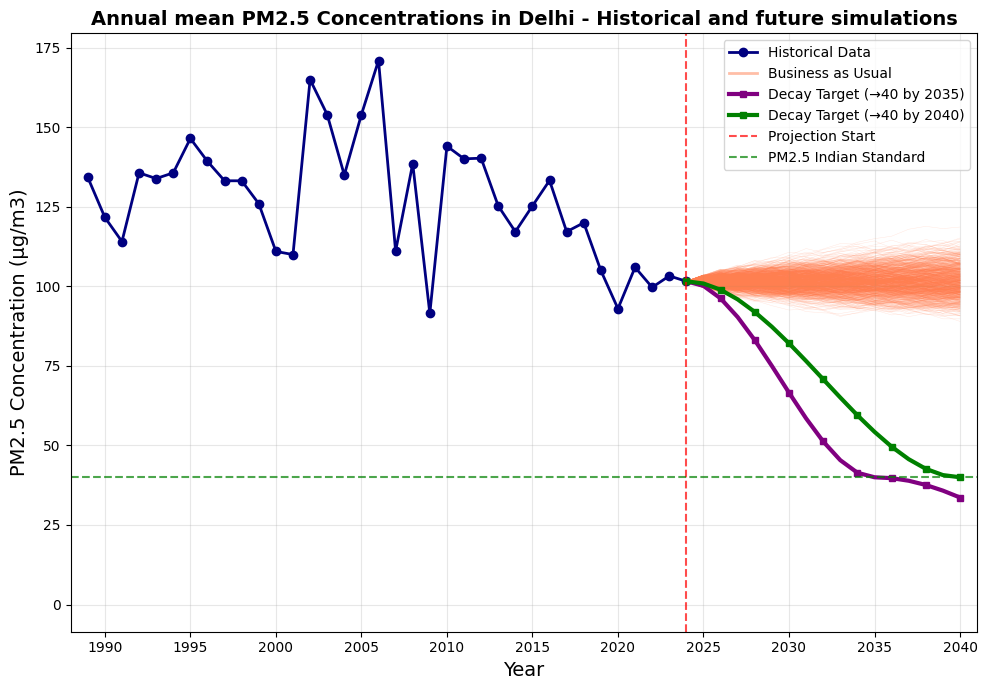

In [23]:
# Visualization
from matplotlib.lines import Line2D
fig, axes = plt.subplots(1, 1, figsize=(10, 7))

# Plot 1: Historical data and sample simulations
ax1 = axes
ax1.plot(years, observations, 'o-', linewidth=2, markersize=6, 
         label='Historical Data', color='navy')
future_years = np.arange(2024, 2041)
for i in range(min(1000, n_simulations)):  # Plot first 50 simulations
    ax1.plot(future_years, np.insert(simulations[i, :], 0, 101.6), alpha=0.2, linewidth=0.3, color='coral')

# Add a proxy line for coral simulations (for legend)
proxy_sim_line = Line2D([0], [0], color='coral', lw=2, alpha=0.5, label='Business as Usual')
ax1.add_line(proxy_sim_line)

ax1.plot(future_years, decay_values2035, linewidth=3, linestyle='-', 
         color='purple', label='Decay Target (→40 by 2035)', marker='s', 
         markersize=4, markevery=2)

ax1.plot(future_years, decay_values2040, linewidth=3, linestyle='-', 
         color='green', label='Decay Target (→40 by 2040)', marker='s', 
         markersize=4, markevery=2)

ax1.axvline(x=2024, color='red', linestyle='--', alpha=0.7, label='Projection Start')
ax1.axhline(y=40, color='green', linestyle='--', alpha=0.7, label='PM2.5 Indian Standard')

ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('PM2.5 Concentration (μg/m3)', fontsize=14)
ax1.set_title('Annual mean PM2.5 Concentrations in Delhi - Historical and future simulations', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
# Set X-axis ticks to show every 5 years
ax1.set_xticks(np.arange(1985, 2045, 5))
ax1.set_xlim(1988, 2041)

plt.tight_layout()
plt.savefig('DelhiPM2.5projections.jpg')

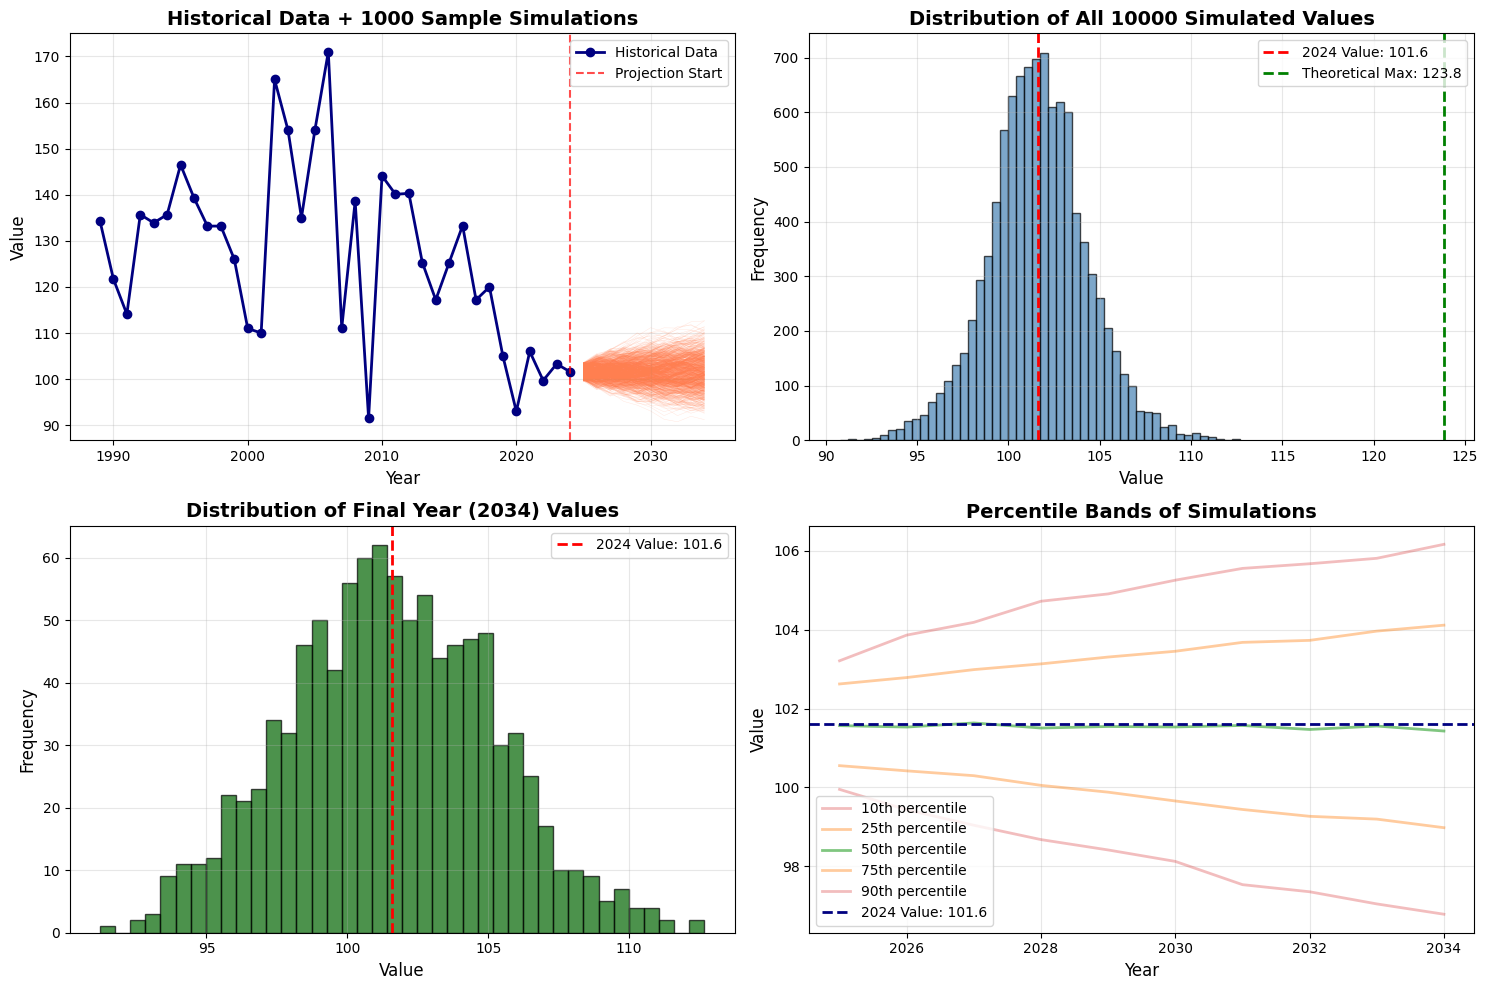

In [50]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Historical data and sample simulations
ax1 = axes[0, 0]
ax1.plot(years, observations, 'o-', linewidth=2, markersize=6, 
         label='Historical Data', color='navy')
future_years = np.arange(2025, 2035)
for i in range(min(1000, n_simulations)):  # Plot first 50 simulations
    ax1.plot(future_years, simulations[i, :], alpha=0.2, linewidth=0.3, color='coral')
ax1.axvline(x=2024, color='red', linestyle='--', alpha=0.7, label='Projection Start')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Value', fontsize=12)
ax1.set_title('Historical Data + 1000 Sample Simulations', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of all simulated values
ax2 = axes[0, 1]
ax2.hist(all_simulated_values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(x=last_value, color='red', linestyle='--', linewidth=2, label=f'2024 Value: {last_value}')
ax2.axvline(x=last_value * (1.02**10), color='green', linestyle='--', linewidth=2, 
            label=f'Theoretical Max: {last_value * (1.02**10):.1f}')
ax2.set_xlabel('Value', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title(f'Distribution of All {len(all_simulated_values)} Simulated Values', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Distribution of final year values (2034)
ax3 = axes[1, 0]
ax3.hist(final_values, bins=40, edgecolor='black', alpha=0.7, color='darkgreen')
ax3.axvline(x=last_value, color='red', linestyle='--', linewidth=2, label=f'2024 Value: {last_value}')
ax3.set_xlabel('Value', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Distribution of Final Year (2034) Values', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Percentile bands over time
ax4 = axes[1, 1]
percentiles = [10, 25, 50, 75, 90]
percentile_values = np.percentile(simulations, percentiles, axis=0)
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#ff7f0e', '#d62728']
alphas = [0.3, 0.4, 0.6, 0.4, 0.3]

for i, p in enumerate(percentiles):
    ax4.plot(future_years, percentile_values[i], label=f'{p}th percentile', 
             linewidth=2, color=colors[i], alpha=alphas[i])
ax4.axhline(y=last_value, color='navy', linestyle='--', linewidth=2, 
            label=f'2024 Value: {last_value}')
ax4.set_xlabel('Year', fontsize=12)
ax4.set_ylabel('Value', fontsize=12)
ax4.set_title('Percentile Bands of Simulations', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Year': future_years,
    'P10': np.percentile(simulations, 10, axis=0),
    'P25': np.percentile(simulations, 25, axis=0),
    'Median': np.percentile(simulations, 50, axis=0),
    'P75': np.percentile(simulations, 75, axis=0),
    'P90': np.percentile(simulations, 90, axis=0),
    'Mean': simulations.mean(axis=0)
})

In [46]:
summary_df

,Year,P10,P25,Median,P75,P90,Mean
0,2025,99.947363,100.550012,101.565832,102.624168,103.211999,101.576207
1,2026,99.429302,100.417836,101.530109,102.786655,103.864105,101.583829
2,2027,99.037224,100.295194,101.633767,102.988042,104.188479,101.632124
3,2028,98.672494,100.049527,101.504866,103.133545,104.724178,101.612674
4,2029,98.409607,99.876731,101.544505,103.307323,104.909937,101.602754
5,2030,98.119117,99.653211,101.532563,103.453914,105.258757,101.576190
6,2031,97.528902,99.437578,101.570041,103.679703,105.557531,101.551513
7,2032,97.348311,99.264034,101.468439,103.730638,105.675709,101.534387
8,2033,97.039968,99.192903,101.555817,103.965514,105.813753,101.529943
9,2034,96.778103,98.975093,101.428929,104.116198,106.168710,101.525868


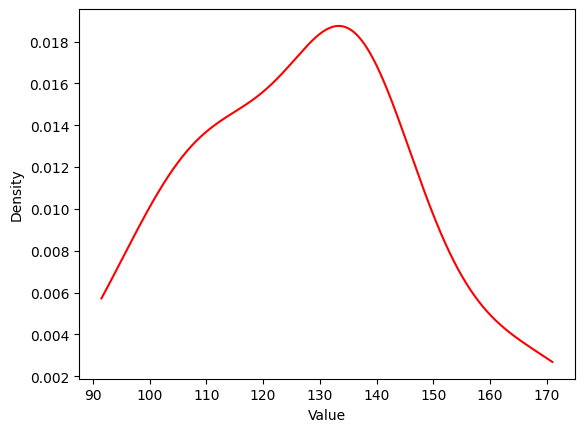

In [21]:
plt.plot(x_values, pdf_values, color='red', label='Empirical PDF (KDE)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [27]:
num_simulations = 10000
path_length = 10
resamples = [kde.resample(size=path_length) for _ in range(num_simulations)]

In [29]:
resamples_array = np.array(resamples)
resamples_array

array([[[138.12319532, 124.92060131, 130.39320918, ...,  85.14842228,
         123.42930563, 132.3648224 ]],

       [[118.97748218, 128.76730114, 157.32894694, ..., 125.50309092,
         134.08751697, 116.10534623]],

       [[113.32807273, 142.15176538,  94.06093533, ..., 160.57058662,
         112.09498609, 132.24326841]],

       ...,

       [[142.9403139 , 119.424828  , 137.63751883, ..., 106.10197865,
         102.11729065, 108.05669071]],

       [[126.71696872, 131.77492581, 117.87842775, ..., 153.77212334,
         106.67105907, 113.54149709]],

       [[ 92.19130098, 110.43526093, 127.82810393, ..., 120.80970696,
         108.19209606, 147.2472941 ]]], shape=(10000, 1, 10))

In [30]:
initial_value = 100
simulated_paths  = initial_value * np.cumprod(1+resamples_array,axis=1)

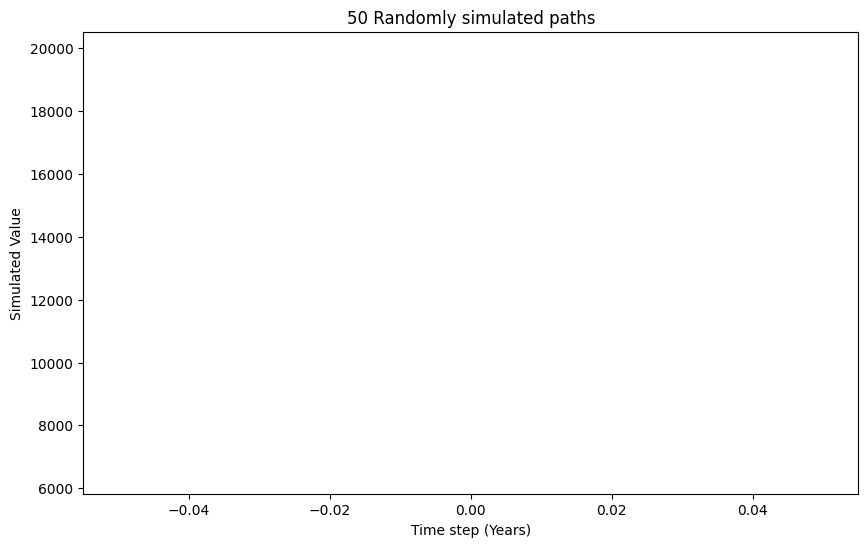

In [32]:
plt.figure(figsize=(10,6))
for i in np.random.choice(range(num_simulations),50):
    plt.plot(simulated_paths[i],color='gray', alpha=0.3)

plt.title('50 Randomly simulated paths')
plt.xlabel('Time step (Years)')
plt.ylabel('Simulated Value')
plt.show()

In [37]:
resamples_array[3,:,:].mean()

np.float64(131.49923512648178)

# Animation

In [432]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
observations = np.array([125.3, 133.3, 117.2, 120.0, 105.0,
                        93.0, 106.0, 99.7, 103.3, 101.6])
years_obs = np.arange(2015,2025)

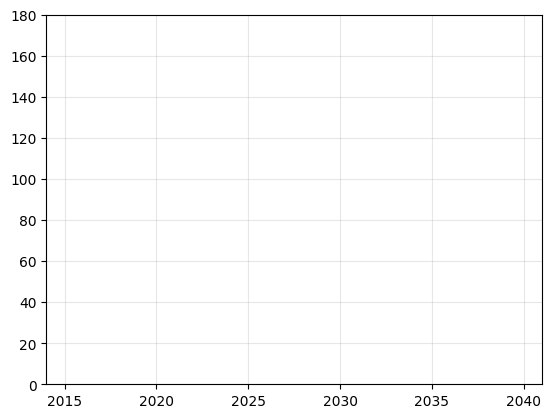

In [434]:
fig, ax = plt.subplots() #figsize=(16, 8)
ax.set_ylim(0, 180) 
# Set X-axis ticks to show every 5 years
ax.set_xticks(np.arange(2015, 2045, 5))
ax.set_xlim(2014, 2041)
ax.grid(True, alpha=0.3)

In [435]:
# Create a single line object
line, = ax.plot([], [], 'o-', linewidth=2, markersize=6, 
         label='Historical Data', color='navy',)

# Initialize empty lists for data
x_data = []
y_data = []

In [436]:
def init():
    line.set_data([], [])
    return [line]

In [437]:
# Animation function: this is called sequentially
def animate(frame): #frame=year_index

    # Append the new data point
    x_data.append(years_obs[frame])
    y_data.append(observations[frame])

    # Update the line with accumulated data
    line.set_data(x_data, y_data)
    

    return [line] 

In [438]:
# Create the animation
from matplotlib.animation import FuncAnimation
ani = FuncAnimation(fig,
                    func = animate,
                    frames= len(years_obs),
                    init_func=init,
                    interval=700,
                    blit=True,
                    repeat=False,
                    save_count=len(observations))
ax.legend()

/tmp/ipykernel_8395/988529243.py:3: UserWarning: You passed in an explicit save_count=10 which is being ignored in favor of frames=10.
  ani = FuncAnimation(fig,


In [439]:
ani.save('anime.mp4',dpi=300) 

In [440]:
plt.close() 

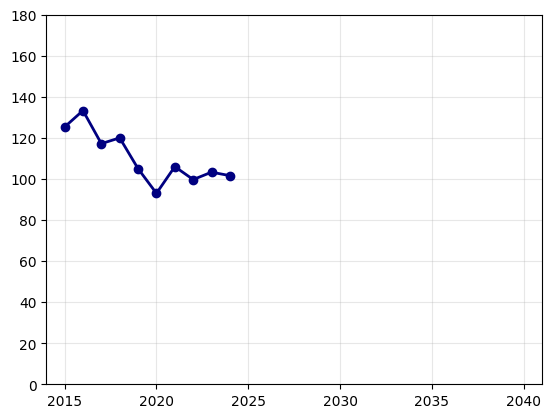

In [441]:
fig, ax = plt.subplots() #figsize=(16, 8)
ax.set_ylim(0, 180) 
# Set X-axis ticks to show every 5 years
ax.set_xticks(np.arange(2015, 2045, 5))
ax.set_xlim(2014, 2041)
ax.grid(True, alpha=0.3)
ax.plot(years_obs, observations, 'o-', linewidth=2, markersize=6, 
         label='Historical Data', color='navy')

#ax.legend()

In [442]:
allyears = np.arange(2014,2042)

In [443]:
# Create a single line object

line1, = ax.plot([], [], '--', linewidth=1,
          color='green',)

line2, = ax.plot([], [], '--', linewidth=1,
         color='darkgreen',)
# Initialize empty lists for data
x_data = []
y_data = []

In [444]:
# Animation function: this is called sequentially
def animate(frame): #frame=year_index
    if frame%len(allyears) ==0:
        x_data.clear()
        y_data.clear()

    # Update the line with accumulated data
    if frame<len(allyears):
        # Append the new data point
        x_data.append(2014+(frame%len(allyears)))
        y_data.append(40)
        line1.set_data(x_data,
         y_data)
    else:
        x_data.append(2014+(frame%len(allyears)))
        y_data.append(5)
        line2.set_data(x_data,
         y_data)    
    return [line1,line2]

In [445]:
# Create the animation
from matplotlib.animation import FuncAnimation

ani = FuncAnimation(fig,
                    func = animate,
                    frames= len(allyears)*2,
                    init_func=init,
                    interval=75,
                    blit=True,
                    repeat=False,
                    save_count=len(allyears)*2)
ax.legend()

/tmp/ipykernel_8395/2043746147.py:4: UserWarning: You passed in an explicit save_count=56 which is being ignored in favor of frames=56.
  ani = FuncAnimation(fig,


In [446]:
ani.save('anime2.mp4',dpi=300) 

## Montecarlo animation

In [464]:
plt.close()

Text(2014.2, 7.5, 'WHO guideline')

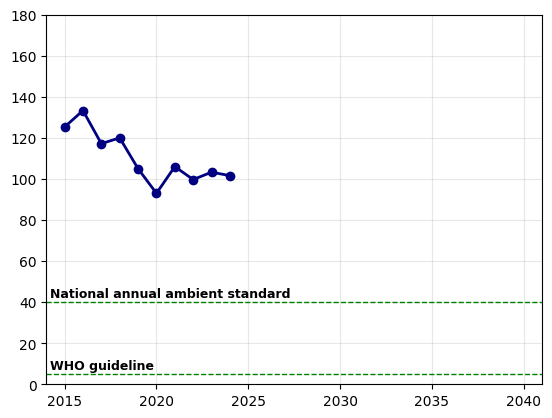

In [465]:
fig, ax = plt.subplots() #figsize=(16, 8)
ax.set_ylim(0, 180) 
# Set X-axis ticks to show every 5 years
ax.set_xticks(np.arange(2015, 2045, 5))
ax.set_xlim(2014, 2041)
ax.grid(True, alpha=0.3)
ax.plot(years_obs, observations, 'o-', linewidth=2, markersize=6, 
         label='Historical Data', color='navy')
ax.axhline(y=40, color='green', linestyle='--',linewidth=1)
ax.axhline(y=5, color='green', linestyle='--',linewidth=1)
ax.annotate(
    'National annual ambient standard',
    xy=(2014.2,42.5),
    weight='bold',size=9
)
ax.annotate(
    'WHO guideline',
    xy=(2014.2,7.5),
    weight='bold',size=9
)

In [466]:
n_simulations

1000

In [467]:
# Create an empty line object for each year
lines = {}

for i in range(n_simulations):
    lines[i], = ax.plot([], [], alpha=0.2, linewidth=0.3, color='coral')



In [468]:
# Initialization function: plot the background of each frame
def init():
    for line in lines.values():
        line.set_data([], [])
    return list(lines.values())

In [469]:
futureyears = np.arange(2025,2041)
x_data = {sim_num: np.arange(2024,2041) for sim_num in range(n_simulations)}
y_data = {sim_num: np.array([101.6]) for sim_num in range(n_simulations)}

In [470]:
def animate(frame): #frame=index
    simulation_number = frame

    # x_data[simulation_number].append(2025+frame%16)
    y_data[simulation_number] = np.append(y_data[simulation_number],simulations[simulation_number]).flatten()

    for sim_num, line in lines.items():
        line.set_data(x_data[sim_num], y_data[sim_num])

    return list(lines.values())

In [471]:
# Create the animation

ani = FuncAnimation(fig,
                    func = animate,
                    frames= len(simulations), #1000 frames
                    init_func=init,
                    interval=10,
                    blit=True,
                    repeat=False,
                    save_count=len(simulations))
ax.legend()

/tmp/ipykernel_8395/3949835434.py:3: UserWarning: You passed in an explicit save_count=1000 which is being ignored in favor of frames=1000.
  ani = FuncAnimation(fig,


In [472]:
from tqdm import tqdm
bar = tqdm(total=len(simulations))

ani.save('anime3.mp4',dpi=300,
        progress_callback=lambda i, n: bar.update(1),) 

#writer = animation.FFMpegWriter(fps=30)
# ani.save(
#     "../../figures/animation/sine-cosine.mp4",
#     writer=writer,
#     dpi=100,
#     progress_callback=lambda i, n: bar.update(1),
# )
bar.close()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [14:16<00:00,  1.17it/s]


# Decay animation

In [447]:
plt.close()

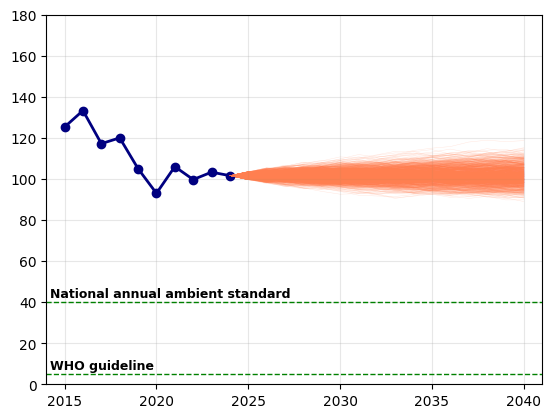

In [448]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots() #figsize=(16, 8)
ax.set_ylim(0, 180) 
# Set X-axis ticks to show every 5 years
ax.set_xticks(np.arange(2015, 2045, 5))
ax.set_xlim(2014, 2041)
ax.grid(True, alpha=0.3)
ax.plot(years_obs, observations, 'o-', linewidth=2, markersize=6, 
         label='Historical Data', color='navy')
ax.axhline(y=40, color='green', linestyle='--',linewidth=1)
ax.axhline(y=5, color='green', linestyle='--',linewidth=1)
ax.annotate(
    'National annual ambient standard',
    xy=(2014.2,42.5),
    weight='bold',size=9
)
ax.annotate(
    'WHO guideline',
    xy=(2014.2,7.5),
    weight='bold',size=9
)

# Add a proxy line for coral simulations (for legend)
proxy_sim_line = Line2D([0], [0], color='coral', lw=2, alpha=0.5, label='Business as Usual')
ax.add_line(proxy_sim_line)
future_years = np.arange(2024, 2041)
for i in range(min(1000, n_simulations)):  # Plot first 100 simulations
    ax.plot(future_years, np.insert(simulations[i, :], 0, 101.6), alpha=0.2, linewidth=0.3, color='coral')

In [449]:
# Create a single line object
line, = ax.plot([], [],linewidth=2, markersize=4, linestyle='-', 
         color='green', marker='s', 
         label='Meet Indian Standard by 2040')

# Initialize empty lists for data
x_data = []
y_data = []

In [450]:
def init():
    line.set_data([], [])
    return [line]

In [8]:
future_observations = np.array([101.6, 101.0, 98.0,
97.3,
95.3,
92.2,
88.2,
83.6,
78.4,
73.0,
67.4,
62.0,
56.9,
52.2,
48.3,
45.2,
43.2])

In [452]:
# Animation function: this is called sequentially
def animate(frame): #frame=year_index

    # Append the new data point
    x_data.append(future_years[frame])
    y_data.append(future_observations[frame])

    # Update the line with accumulated data
    line.set_data(x_data, y_data)
    

    return [line] 

In [453]:
# Create the animation
from matplotlib.animation import FuncAnimation
ani = FuncAnimation(fig,
                    func = animate,
                    frames= len(future_years),
                    init_func=init,
                    interval=400,
                    blit=True,
                    repeat=False,
                    save_count=len(future_years))
ax.legend()

/tmp/ipykernel_8395/1467666351.py:3: UserWarning: You passed in an explicit save_count=17 which is being ignored in favor of frames=17.
  ani = FuncAnimation(fig,


In [454]:
ani.save('anime4.mp4',dpi=300)

In [455]:
plt.close()

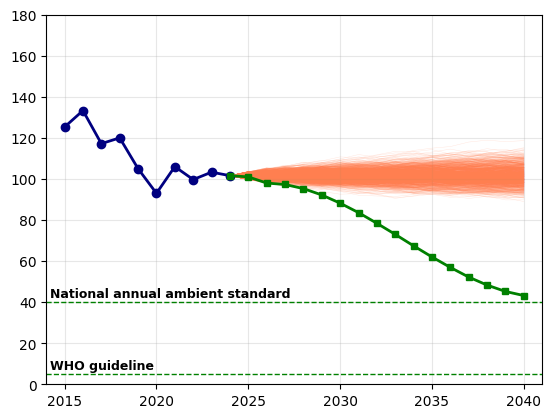

In [456]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots() #figsize=(16, 8)
ax.set_ylim(0, 180) 
# Set X-axis ticks to show every 5 years
ax.set_xticks(np.arange(2015, 2045, 5))
ax.set_xlim(2014, 2041)
ax.grid(True, alpha=0.3)
ax.plot(years_obs, observations, 'o-', linewidth=2, markersize=6, 
         label='Historical Data', color='navy')
ax.axhline(y=40, color='green', linestyle='--',linewidth=1)
ax.axhline(y=5, color='green', linestyle='--',linewidth=1)
ax.annotate(
    'National annual ambient standard',
    xy=(2014.2,42.5),
    weight='bold',size=9
)
ax.annotate(
    'WHO guideline',
    xy=(2014.2,7.5),
    weight='bold',size=9
)

# Add a proxy line for coral simulations (for legend)
proxy_sim_line = Line2D([0], [0], color='coral', lw=2, alpha=0.5, label='Business as Usual')
ax.add_line(proxy_sim_line)
future_years = np.arange(2024, 2041)
for i in range(min(1000, n_simulations)):  # Plot first 100 simulations
    ax.plot(future_years, np.insert(simulations[i, :], 0, 101.6), alpha=0.2, linewidth=0.3, color='coral')

ax.plot(future_years, future_observations, linewidth=2, markersize=4, linestyle='-', 
         color='green', marker='s', 
         label='Meet Indian Standard by 2040')

In [457]:
# Create a single line object
line, = ax.plot([], [],linewidth=2, markersize=4, linestyle='-', 
         color='purple', marker='s', 
         label='Meet Indian Standard by 2035')

# Initialize empty lists for data
x_data = []
y_data = []

In [10]:
future_observations2 = np.array([101.6,101.0,
98.0,
97.0,
94.1,
89.8,
84.1,
77.5,
70.2,
62.5,
54.6,
46.9,
39.6,
33.0,
27.3,
23.0,
20.1,
])

In [459]:
# Animation function: this is called sequentially
def animate(frame): #frame=year_index

    # Append the new data point
    x_data.append(future_years[frame])
    y_data.append(future_observations2[frame])

    # Update the line with accumulated data
    line.set_data(x_data, y_data)
    

    return [line] 

In [460]:
# Create the animation
from matplotlib.animation import FuncAnimation
ani = FuncAnimation(fig,
                    func = animate,
                    frames= len(future_years),
                    init_func=init,
                    interval=400,
                    blit=True,
                    repeat=False,
                    save_count=len(future_years))
ax.legend()

/tmp/ipykernel_8395/1467666351.py:3: UserWarning: You passed in an explicit save_count=17 which is being ignored in favor of frames=17.
  ani = FuncAnimation(fig,


In [461]:
ani.save('anime5.mp4',dpi=300)

In [462]:
plt.close()

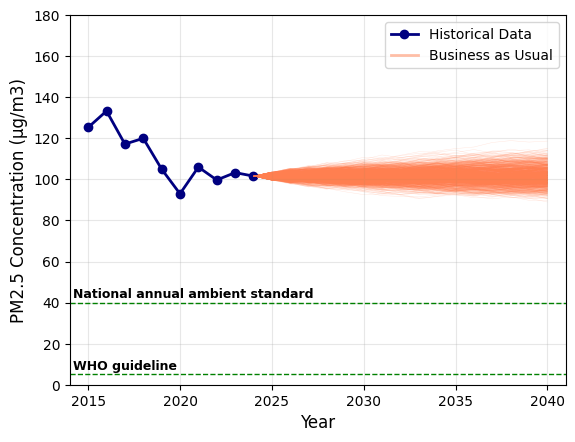

In [10]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots() #figsize=(16, 8)
ax.set_ylim(0, 180) 
# Set X-axis ticks to show every 5 years
ax.set_xticks(np.arange(2015, 2045, 5))
ax.set_xlim(2014, 2041)
ax.grid(True, alpha=0.3)
ax.plot(years_obs, observations, 'o-', linewidth=2, markersize=6, 
         label='Historical Data', color='navy')
ax.axhline(y=40, color='green', linestyle='--',linewidth=1)
ax.axhline(y=5, color='green', linestyle='--',linewidth=1)
ax.annotate(
    'National annual ambient standard',
    xy=(2014.2,42.5),
    weight='bold',size=9
)
ax.annotate(
    'WHO guideline',
    xy=(2014.2,7.5),
    weight='bold',size=9
)

# Add a proxy line for coral simulations (for legend)
proxy_sim_line = Line2D([0], [0], color='coral', lw=2, alpha=0.5, label='Business as Usual')
ax.add_line(proxy_sim_line)
future_years = np.arange(2024, 2041)
for i in range(min(1000, n_simulations)):  # Plot first 100 simulations
    ax.plot(future_years, np.insert(simulations[i, :], 0, 101.6), alpha=0.2, linewidth=0.3, color='coral')

# ax.plot(future_years, future_observations, linewidth=2, markersize=4, linestyle='-', 
#          color='green', marker='s', 
#          label='Meet Indian Standard by 2040')
# ax.plot(future_years, future_observations2, linewidth=2, markersize=4, linestyle='-', 
#          color='purple', marker='s', 
#          label='Meet Indian Standard by 2035')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('PM2.5 Concentration (μg/m3)', fontsize=12)
ax.legend()
plt.savefig('finalplot2.jpg',dpi=300)